# Test Multi-Isotope Covariance Heatmaps

This notebook tests the multi-isotope heatmap visualization feature for `CovMat`.

In [1]:
# Cell 1: Setup
from kika.cov.parse_covmat import read_scale_covmat
from kika.plotting.heatmap_builder import HeatmapBuilder
import matplotlib.pyplot as plt

# Load SCALE covariance data
covmat = read_scale_covmat(r"c:\Users\Usuario\BaradDur\Dev\kika\files\cov\scale.rev05.44groupcov.txt", energy_unit='MeV')

print(f"Isotopes: {covmat.isotopes}")
print(f"Reactions: {covmat.reactions}")
print(f"Number of groups: {covmat.num_groups}")
print(f"Number of matrices: {covmat.num_matrices}")
print(f"Energy unit: {covmat.energy_unit}")
print(f"Energy range: {min(covmat.energy_grid):.2e} to {max(covmat.energy_grid):.2e} {covmat.energy_unit}")

Isotopes: [1001, 1002, 1003, 2003, 2004, 3006, 3007, 4007, 4009, 5010, 5011, 6000, 7014, 7015, 8016, 8017, 9019, 11023, 12000, 12024, 12025, 12026, 13027, 14000, 14028, 14029, 14030, 15031, 16000, 16032, 16033, 16034, 16036, 17000, 17035, 17037, 18036, 18038, 18040, 19000, 19039, 19040, 19041, 20000, 20040, 20042, 20043, 20044, 20046, 20048, 21045, 22000, 22046, 22047, 22048, 22049, 22050, 23000, 24050, 24052, 24053, 24054, 25055, 26054, 26056, 26057, 26058, 27058, 27059, 28058, 28059, 28060, 28061, 28062, 28064, 29063, 29065, 31000, 31069, 31071, 32070, 32072, 32073, 32074, 32076, 33074, 33075, 34074, 34076, 34077, 34078, 34079, 34080, 34082, 35079, 35081, 36078, 36080, 36082, 36083, 36084, 36085, 36086, 37085, 37086, 37087, 38084, 38086, 38087, 38088, 38089, 38090, 39089, 39090, 39091, 40000, 40090, 40091, 40092, 40093, 40094, 40095, 40096, 41093, 41094, 41095, 42000, 42092, 42094, 42095, 42096, 42097, 42098, 42099, 42100, 43099, 44096, 44098, 44099, 44100, 44101, 44102, 44103, 44104

## Cell 2: Single Block Tests

Basic single-isotope, single-MT tests (backward compatibility)

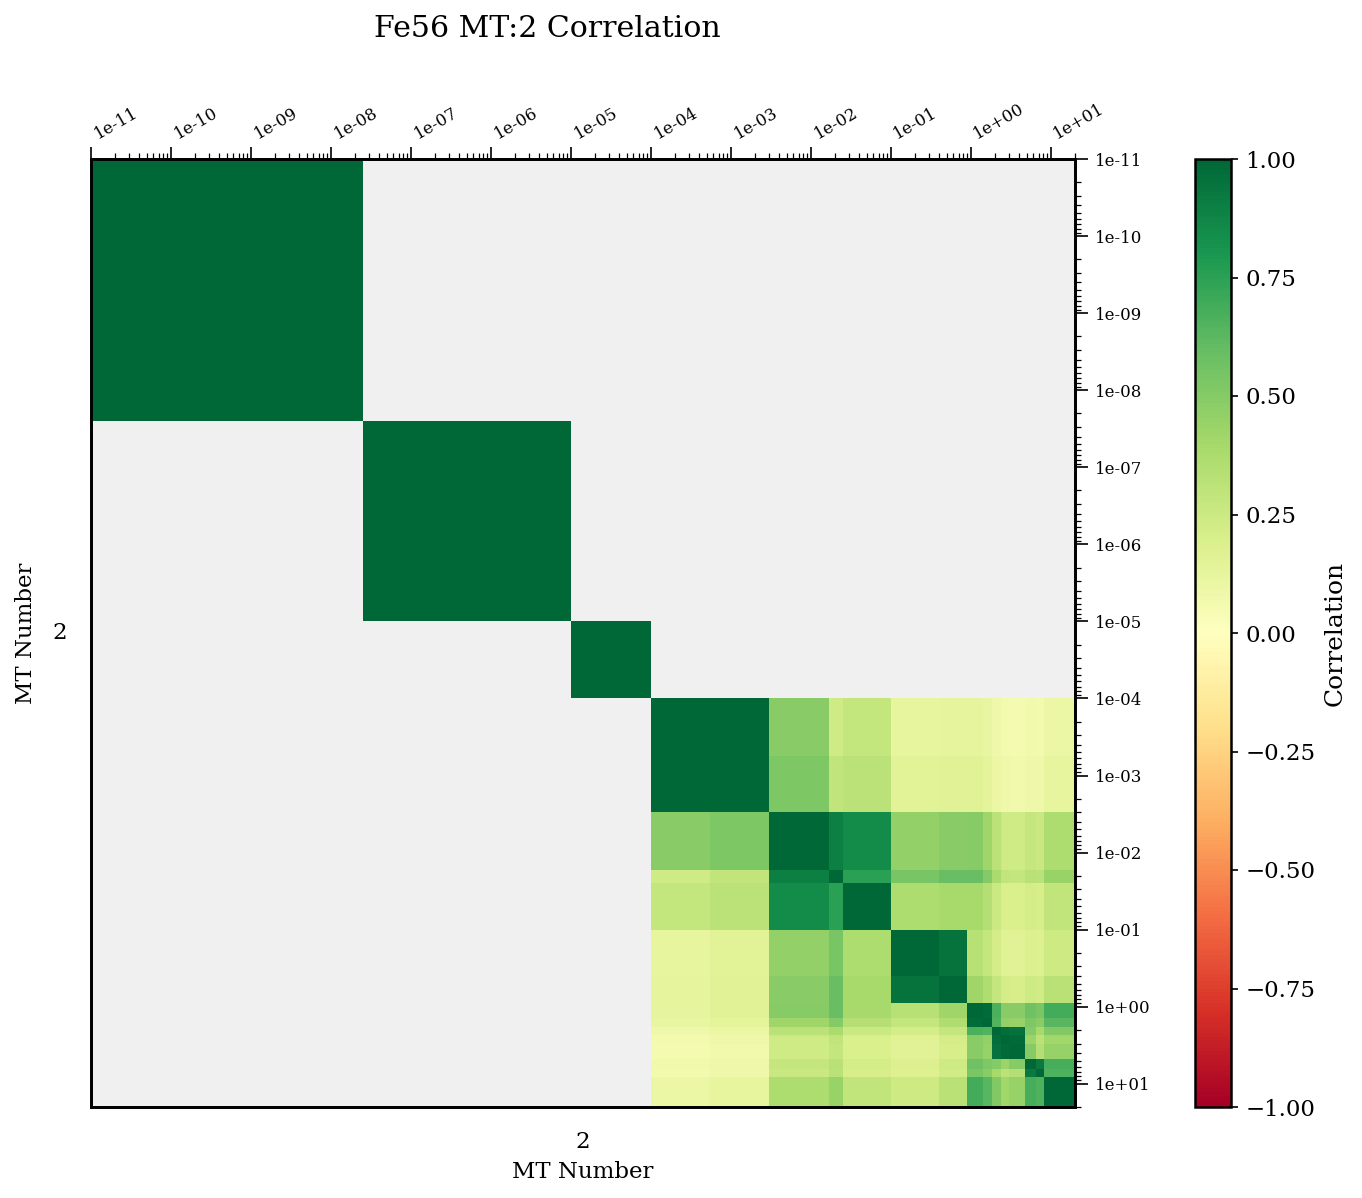

In [2]:
# Basic single block (one isotope, one MT)
heatmap_data = covmat.to_heatmap_data(nuclide=26056, mt=2)
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

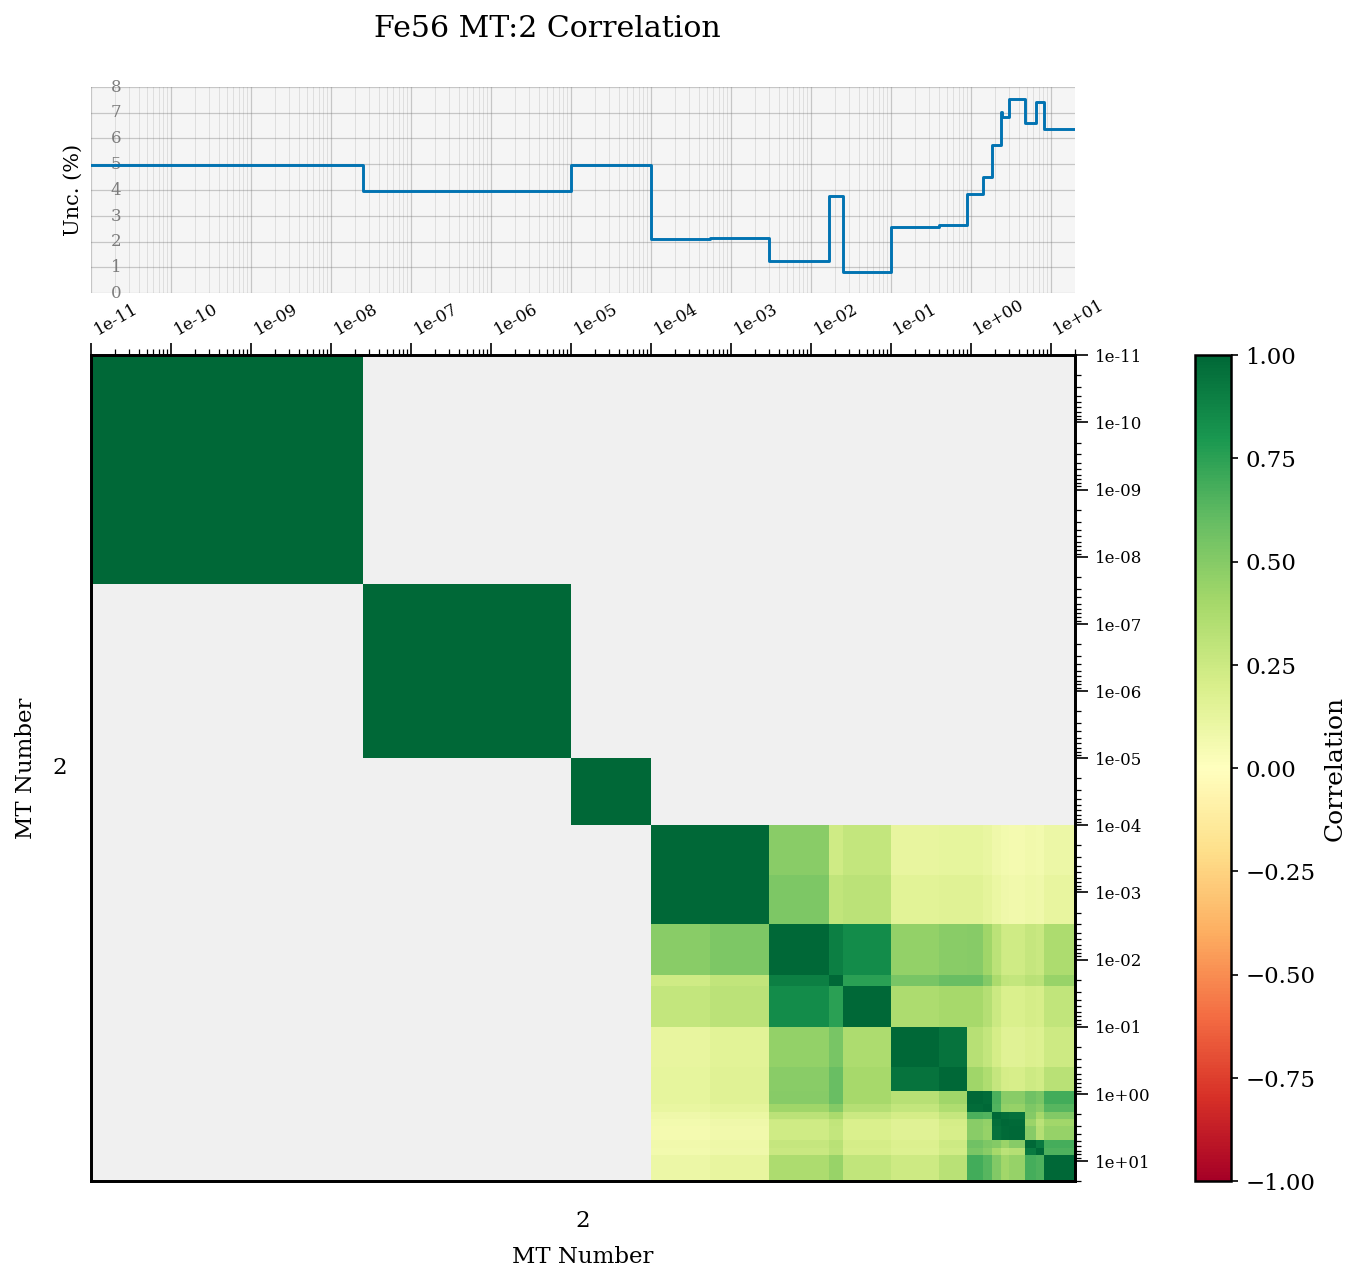

In [3]:
# With uncertainties
heatmap_data = covmat.to_heatmap_data(nuclide='Fe56', mt=2)
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=True).build()
plt.show()

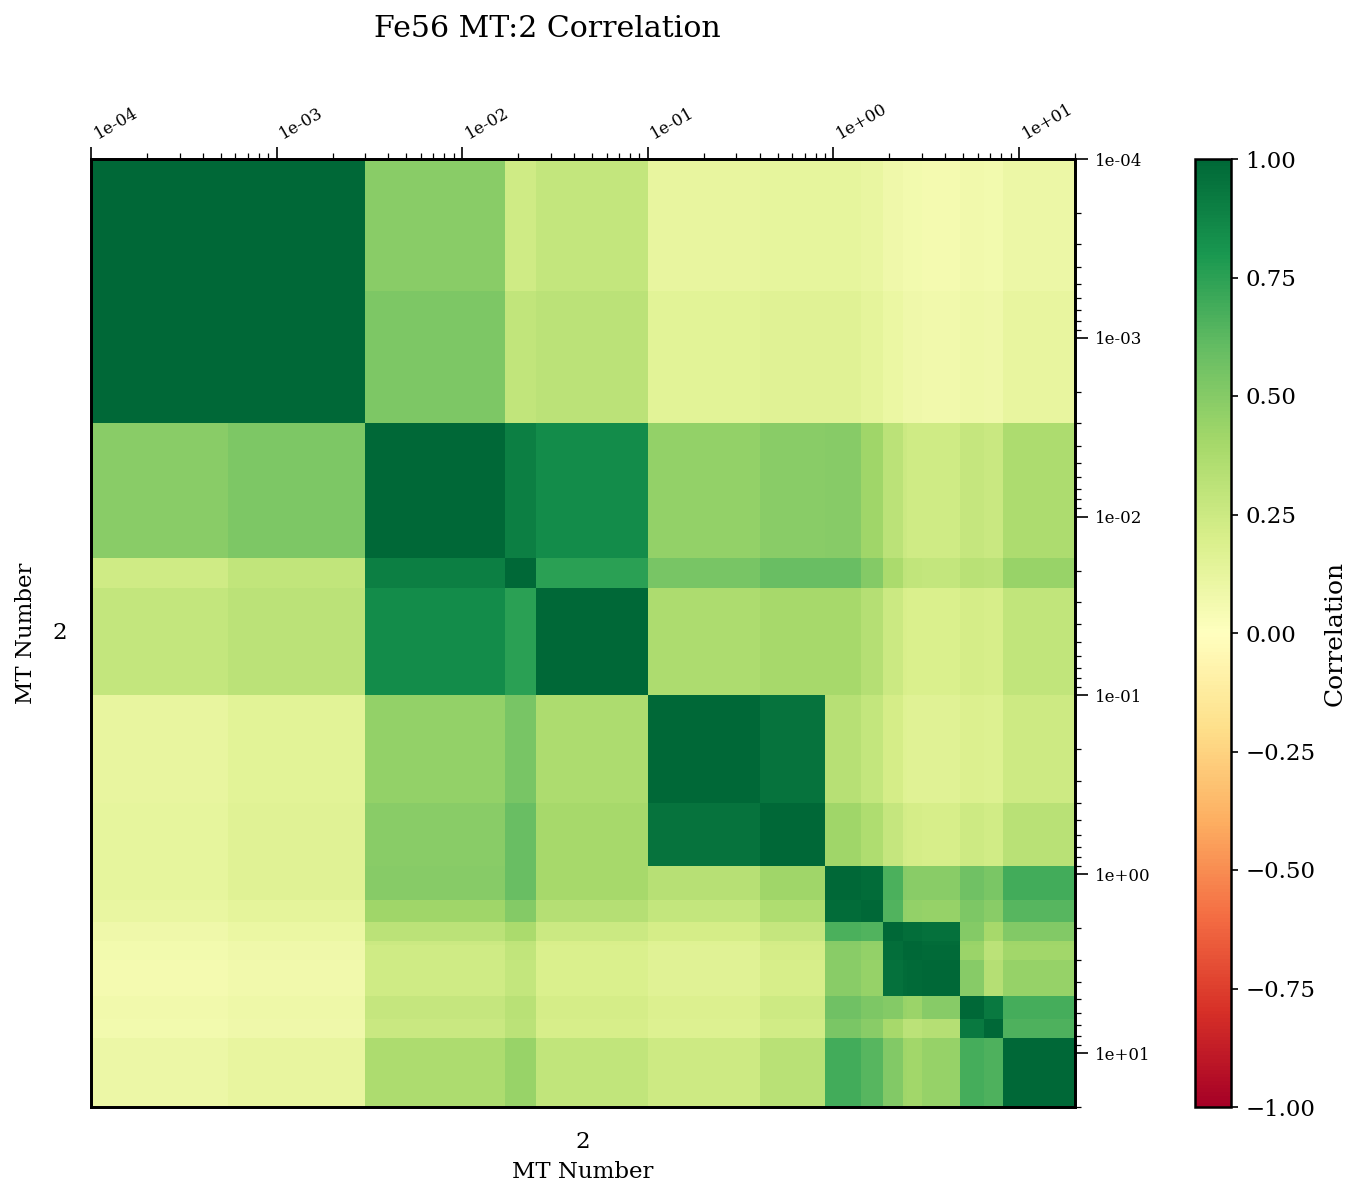

In [ ]:
# With energy filtering (energy_range is in eV)
heatmap_data = covmat.to_heatmap_data(nuclide='Fe56', mt=2, energy_range=(1e4, 1e7))
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

In [ ]:
# With energy filtering + uncertainties
heatmap_data = covmat.to_heatmap_data(nuclide='Fe56', mt=2, energy_range=(1e4, 1e7))
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=True).build()
plt.show()

## Cell 3: Multi-MT Tests (Single Isotope)

Multiple MTs for a single isotope

In [ ]:
# Multiple MTs diagonal blocks
heatmap_data = covmat.to_heatmap_data(nuclide='Fe56', mt=[2, 4])
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

In [ ]:
# With uncertainties
heatmap_data = covmat.to_heatmap_data(nuclide='Fe56', mt=[2, 4])
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=True).build()
plt.show()

In [ ]:
# With energy filtering
heatmap_data = covmat.to_heatmap_data(nuclide='Fe56', mt=[2, 4], energy_range=(1e4, 1e7))
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

## Cell 4: Multi-Isotope Tests

NEW FEATURE: Multiple isotopes with cross-isotope correlations

In [ ]:
# First, let's see which isotopes have data for MT=2
# Check which isotopes have MT 2
reactions_by_iso = covmat.reactions_by_isotope()
isotopes_with_mt2 = [iso for iso, mts in reactions_by_iso.items() if 2 in mts]
print(f"Isotopes with MT=2: {isotopes_with_mt2[:10]}...")  # Show first 10

# Check Fe isotopes MTs
print(f"\nFe54 MTs: {covmat.reactions_by_isotope(26054)}")
print(f"Fe56 MTs: {covmat.reactions_by_isotope(26056)}")

In [ ]:
# Multiple isotopes, same MT
# Using iron isotopes
heatmap_data = covmat.to_heatmap_data(nuclide=[26054, 26056], mt=2)
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

In [ ]:
# Multiple isotopes, multiple MTs
heatmap_data = covmat.to_heatmap_data(nuclide=[26054, 26056], mt=[2, 4])
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

In [ ]:
# Using string nuclide identifiers
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4])
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

In [ ]:
# Multi-isotope with uncertainties
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4])
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=True).build()
plt.show()

In [ ]:
# Multi-isotope with energy filtering (in eV)
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4], energy_range=(1e4, 1e7))
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

In [ ]:
# Multi-isotope with energy filtering + uncertainties
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4], 
                                       energy_range=(1e4, 1e7))
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=True).build()
plt.show()

In [ ]:
# Multi-isotope with custom title
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4])
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data, show_uncertainties=False)
       .set_labels(title="Fe54/Fe56 Cross-Isotope Correlations")
       .build())
plt.show()

## Cell 5: Off-Diagonal Tests

In [ ]:
# Single isotope off-diagonal (mt=(2, 4))
heatmap_data = covmat.to_heatmap_data(nuclide='Fe56', mt=(2, 4))
fig = HeatmapBuilder().add_heatmap(heatmap_data, show_uncertainties=False).build()
plt.show()

## Cell 6: Verification of block_info structure

In [ ]:
# Verify block_info structure for multi-isotope
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4])

print("block_info:")
for key, value in heatmap_data.block_info.items():
    print(f"  {key}: {value}")

print(f"\nmt_labels: {heatmap_data.mt_labels}")
print(f"zaid: {heatmap_data.zaid}")
print(f"is_diagonal: {heatmap_data.is_diagonal}")
print(f"matrix_data shape: {heatmap_data.matrix_data.shape}")
print(f"label (title): {heatmap_data.label}")

In [ ]:
# Verify uncertainty_data keys
if heatmap_data.uncertainty_data:
    print("uncertainty_data keys:")
    for key in heatmap_data.uncertainty_data.keys():
        print(f"  {key}: shape={heatmap_data.uncertainty_data[key].shape}")

In [ ]:
# Compare with single-isotope block_info
heatmap_data_single = covmat.to_heatmap_data(nuclide='Fe56', mt=[2, 4])

print("Single-isotope block_info:")
for key, value in heatmap_data_single.block_info.items():
    print(f"  {key}: {value}")

print(f"\nmt_labels: {heatmap_data_single.mt_labels}")
print(f"zaid: {heatmap_data_single.zaid}")

In [ ]:
# Verify energy grid is in eV
print(f"Energy grid (should be in eV): {heatmap_data.energy_grid[:5]}... to ...{heatmap_data.energy_grid[-5:]}")
print(f"Energy grid min: {heatmap_data.energy_grid.min():.2e} eV")
print(f"Energy grid max: {heatmap_data.energy_grid.max():.2e} eV")

## Cell 7: Test filter_by_isotopes method

In [ ]:
# Test the new filter_by_isotopes method
filtered = covmat.filter_by_isotopes([26054, 26056])

print(f"Original CovMat: {covmat.num_matrices} matrices, isotopes: {len(covmat.isotopes)}")
print(f"Filtered CovMat: {filtered.num_matrices} matrices, isotopes: {filtered.isotopes}")
print(f"\nFiltered reactions by isotope:")
for iso, mts in filtered.reactions_by_isotope().items():
    print(f"  {iso}: {mts}")

## Cell 8: HeatmapBuilder customization options

In [ ]:
# Customize HeatmapBuilder options
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4])

fig = (HeatmapBuilder(figsize=(10, 10), dpi=100)
       .add_heatmap(
           heatmap_data,
           show_uncertainties=True,
           show_energy_ticks=True,
           show_block_labels=True,
           show_colorbar=True,
           block_label_fontsize=10,
           energy_tick_fontsize=7
       )
       .set_labels(title="Custom Multi-Isotope Heatmap")
       .build())
plt.show()

In [ ]:
# Without energy ticks
heatmap_data = covmat.to_heatmap_data(nuclide=['Fe54', 'Fe56'], mt=[2, 4])

fig = (HeatmapBuilder(figsize=(8, 8))
       .add_heatmap(
           heatmap_data,
           show_uncertainties=False,
           show_energy_ticks=False,
           show_block_labels=True
       )
       .build())
plt.show()

## Summary

Verification checklist:
- [ ] Single isotope heatmaps work unchanged (backward compatibility)
- [ ] Multi-isotope heatmaps show all blocks correctly
- [ ] Cross-isotope correlation blocks render properly
- [ ] Uncertainty panels work with multi-isotope data
- [ ] Energy filtering works with multi-isotope data
- [ ] Block boundaries draw at correct positions
- [ ] Labels show "Isotope-MT" format (e.g., "Fe56-MT2")
- [ ] String nuclide identifiers work (e.g., 'Fe56')
- [ ] Off-diagonal block selection works
- [ ] Energy grid is converted to eV
- [ ] No default title (title is None unless set by user)